# Field visualization notebook

Consider three electric charges:
- $1.0\times10^{-9}$ C at $(x,y) = (-1.0, 0.0)$
- $1.0\times10^{-9}$ C at $(x,y) = (1.0, 0.0)$
- $-1.5\times10^{-9}$ C at $(x,y) = (0.0, 1.5)$

To describe the electrical properties of this charge distribution, we can use:
- Electric potential (scalar field)
- Electric field (vector field)

Each of these can be represented in different ways.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from pathlib import Path

# --- Physical setup ---------------------------------------------------
k = 8.9875517923e9  # Coulomb's constant, N*m^2/C^2

charges = [
    {"q": 1.0e-9, "pos": np.array([-1.0, 0.0])},   # positive
    {"q": 1.0e-9, "pos": np.array([1.0, 0.0])},    # positive
    {"q": -1.5e-9, "pos": np.array([0.0, 1.5])},   # negative
]

r_min = 0.08  # keep V and E finite at the charges

# --- Grid ---------------------------------------------------------------
max_distance = 3.0
n = 400
x = np.linspace(-max_distance, max_distance, n)
y = np.linspace(-max_distance, max_distance, n)
X, Y = np.meshgrid(x, y)



## Electric potential

Scalar fields can be represented an elevation map or a contour plot.

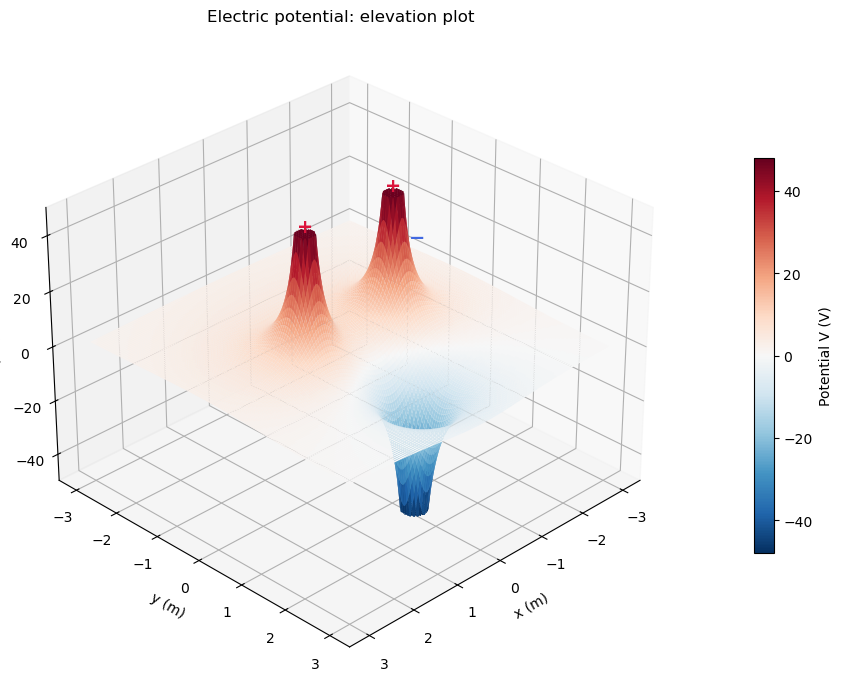

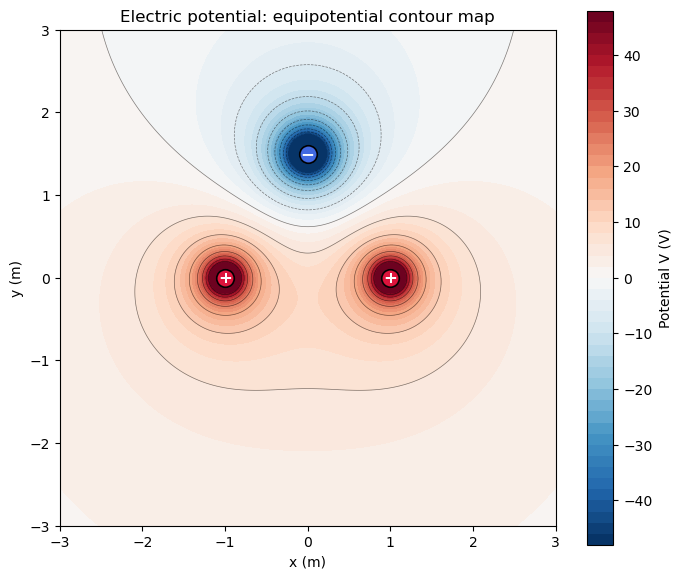

In [3]:
def potential(X, Y, charges, r_min=r_min):
    V = np.zeros_like(X)
    for c in charges:
        dx = X - c["pos"][0]
        dy = Y - c["pos"][1]
        r = np.maximum(np.sqrt(dx**2 + dy**2), r_min)
        V += k * c["q"] / r
    return V

V = potential(X, Y, charges)

# Clip the potential for display so the colormap isn't dominated by the
# near-singular values right next to each charge.
V_clip = np.percentile(np.abs(V), 99)
V_plot = np.clip(V, -V_clip, V_clip)
pot_norm = TwoSlopeNorm(vmin=-V_clip, vcenter=0.0, vmax=V_clip)

def draw_charges(ax, three_d=False, z=0.0):
    """Mark charge locations with red (+) / blue (-) circles."""
    for c in charges:
        color = "crimson" if c["q"] > 0 else "royalblue"
        sign = "+" if c["q"] > 0 else "−"
        px, py = c["pos"]
        if three_d:
            ax.text(px, py, z, sign, color=color, fontsize=14,
                     fontweight="bold", ha="center", va="center", zorder=5)
        else:
            ax.scatter(px, py, s=160, facecolor=color, edgecolor="black",
                       linewidth=1.2, zorder=5)
            ax.text(px, py, sign, color="white", fontsize=12,
                     fontweight="bold", ha="center", va="center", zorder=6)

fig1 = plt.figure(figsize=(9, 7))
ax1 = fig1.add_subplot(111, projection="3d")
surf = ax1.plot_surface(X, Y, V_plot, cmap="RdBu_r", norm=pot_norm,
                          linewidth=0, antialiased=True, rcount=150, ccount=150)
draw_charges(ax1, three_d=True, z=V_clip * 1.05)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")
ax1.set_zlabel("V (V)")
ax1.set_title("Electric potential: elevation plot")
fig1.colorbar(surf, ax=ax1, shrink=0.6, pad=0.1, label="Potential V (V)")
ax1.view_init(elev=30, azim=45, roll=0)
fig1.tight_layout()

fig2, ax2 = plt.subplots(figsize=(7, 6))
cf = ax2.contourf(X, Y, V_plot, levels=60, cmap="RdBu_r", norm=pot_norm)
ax2.contour(X, Y, V_plot, levels=15, colors="black", linewidths=0.5, alpha=0.5)
draw_charges(ax2)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")
ax2.set_title("Electric potential: equipotential contour map")
ax2.set_aspect("equal")
fig2.colorbar(cf, ax=ax2, label="Potential V (V)")
fig2.tight_layout()

## Electric field

Vector fields can be represented using arrows or field lines. 

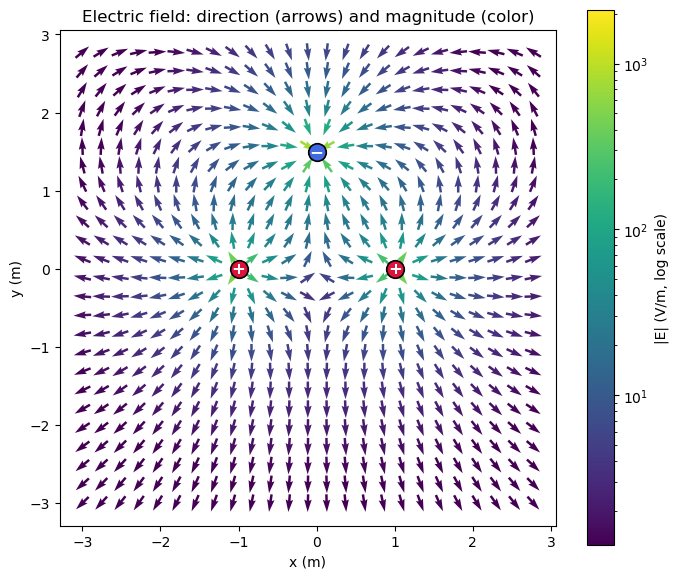

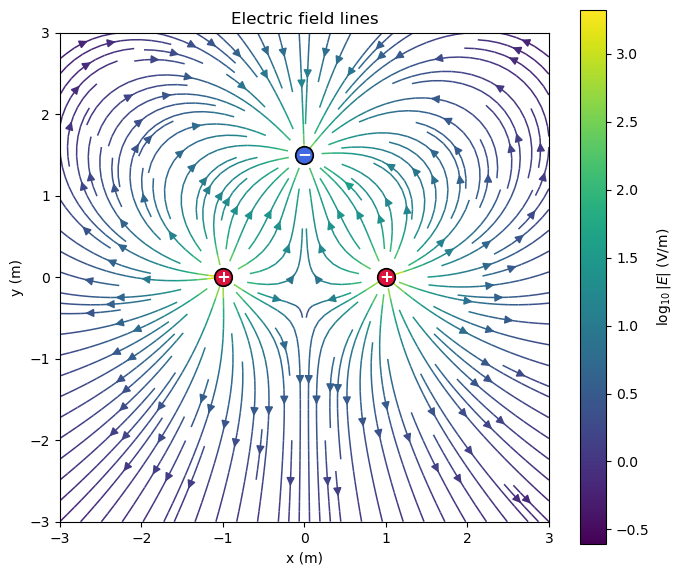

In [4]:
def field(X, Y, charges, r_min=r_min):
    Ex, Ey = np.zeros_like(X), np.zeros_like(X)
    for c in charges:
        dx, dy = X - c["pos"][0], Y - c["pos"][1]
        r = np.maximum(np.sqrt(dx**2 + dy**2), r_min)
        Ex += k * c["q"] * dx / r**3
        Ey += k * c["q"] * dy / r**3
    return Ex, Ey

Ex, Ey = field(X, Y, charges)
E_mag = np.sqrt(Ex**2 + Ey**2)

fig3, ax3 = plt.subplots(figsize=(7, 6))

# Subsample the grid so individual arrows stay legible.
step = 16
Xq, Yq = X[::step, ::step], Y[::step, ::step]
Exq, Eyq = Ex[::step, ::step], Ey[::step, ::step]
Eq_mag = np.sqrt(Exq**2 + Eyq**2)

# Show direction with unit-length arrows; encode magnitude with color
# (log scale, since |E| varies over several orders of magnitude).
Exq_dir = Exq / Eq_mag
Eyq_dir = Eyq / Eq_mag
q = ax3.quiver(Xq, Yq, Exq_dir, Eyq_dir, Eq_mag, cmap="viridis",
                norm=LogNorm(vmin=E_mag.min() + 1, vmax=E_mag.max()),
                pivot="mid", scale=28, width=0.005)
draw_charges(ax3)
ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")
ax3.set_title("Electric field: direction (arrows) and magnitude (color)")
ax3.set_aspect("equal")
fig3.colorbar(q, ax=ax3, label="|E| (V/m, log scale)")
fig3.tight_layout()

fig4, ax4 = plt.subplots(figsize=(7, 6))
strm = ax4.streamplot(X, Y, Ex, Ey, color=np.log10(E_mag), cmap="viridis",
                        density=1.6, linewidth=1.1, arrowsize=1.2)
draw_charges(ax4)
ax4.set_xlabel("x (m)")
ax4.set_ylabel("y (m)")
ax4.set_title("Electric field lines")
ax4.set_aspect("equal")
fig4.colorbar(strm.lines, ax=ax4, label=r"$\log_{10}|E|$ (V/m)")
fig4.tight_layout()